# 3.0 Model training - Ridge


## Imports


In [25]:
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    evaluate_model,
    create_model_gridsearch
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred, convert_to_serializable,get_format
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

In [2]:
ALPHA = 1000
CV_SPLITS = 5
TEST_SIZE = 0.2
DROP_COLUMNS = [AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, VISITORS_NBR_COL, DAY_OF_WEEK_COL, CITY_COL]

MODEL_PATH = MODELS_DIR / "ridge_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Features shape: (271221, 50)
Labels shape: (271221,)


In [4]:
original_index = features.index.copy()
features = prepare_features(features)

labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [5]:
dates = features[VISIT_DATE_COL].copy()
X = features
y = labels

In [6]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, shuffle=False, random_state=42
)
X_train = X_train_full.drop(columns=DROP_COLUMNS)
X_test = X_test_full.drop(columns=DROP_COLUMNS)

split_idx = len(X_train)
train_dates = dates.iloc[:split_idx].reset_index(drop=True)
test_dates = dates.iloc[split_idx:].reset_index(drop=True)

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-02-16 00:00:00
Test set dates: 2017-02-16 00:00:00 to 2017-04-22 00:00:00


## Train


I haven't added the feature update (lags and rolling) yet.

In [9]:
grid_search = create_model_gridsearch(verbose=2)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 3 folds for each of 63 candidates, totalling 189 fits
Best parameters: {'ridge__alpha': np.float64(1000.0), 'selector__estimator__alpha': 0.1, 'selector__threshold': 0.0001}
Best score: -11.385796171998924


In [8]:
model = grid_search.best_estimator_
sel = model.named_steps.get("selector", None)
support = sel.get_support()
selected_cols = X.columns[support]

print("Selected features:", list(selected_cols))

Selected features: ['opened_recently', 'holiday_flg', 'golden_week_flg', 'open_usually', 'days_from_last_visit', 'total_reserves', 'total_reserves_nbrs', 'visitors_mean_7', 'visitors_median_7', 'visitors_nbrs_mean_7', 'visitors_nbrs_std_7', 'visitors_nbrs_median_14', 'visitors_nbrs_median_28', 'visitors_last_month', 'visitors_lag_1', 'visitors_lag_7', 'visitors_lag_28', 'visitors_nbrs_lag_1', 'visitors_dow_mean', 'visitors_dow_mean_nbrs', 'res_visitors_diff', 'res_visitors_diff_mean_14', 'nbr_res_visitors_diff_mean_28']


In [23]:
y_train_pred = model.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

Train set metrics:
RMSE: 11.1049
MAE:  7.2942
R2:   0.5620


In [20]:
y_test_pred, temp_features = recursive_predict(
    model,
    X_test_full,
    X_train_full,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/66 [00:00<?, ?it/s]C:\Users\lymuthien\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:143: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[23.28131881  4.07728088 16.33224744  4.83002632 15.80431243 20.7144581
 18.22848325 22.24209996 36.06484839 12.69157922  5.32760195 17.20030497
 15.38854626 14.21647467 26.5316821   5.54301812 26.06623443 23.40853282
 16.34779632 12.43727475 15.61557478 30.21458903 10.89032347 52.23221542
 11.57085725 12.05732137  5.32963065  8.98058478  0.         10.84178489
 24.86051878 14.54065128 27.78567698  8.64936073 32.13878011 15.91024283
 43.53151633 13.54029071 18.54628623 28.69576431 14.87000981

In [21]:
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSE: 12.3150
MAE:  7.5165
R2:   0.5408


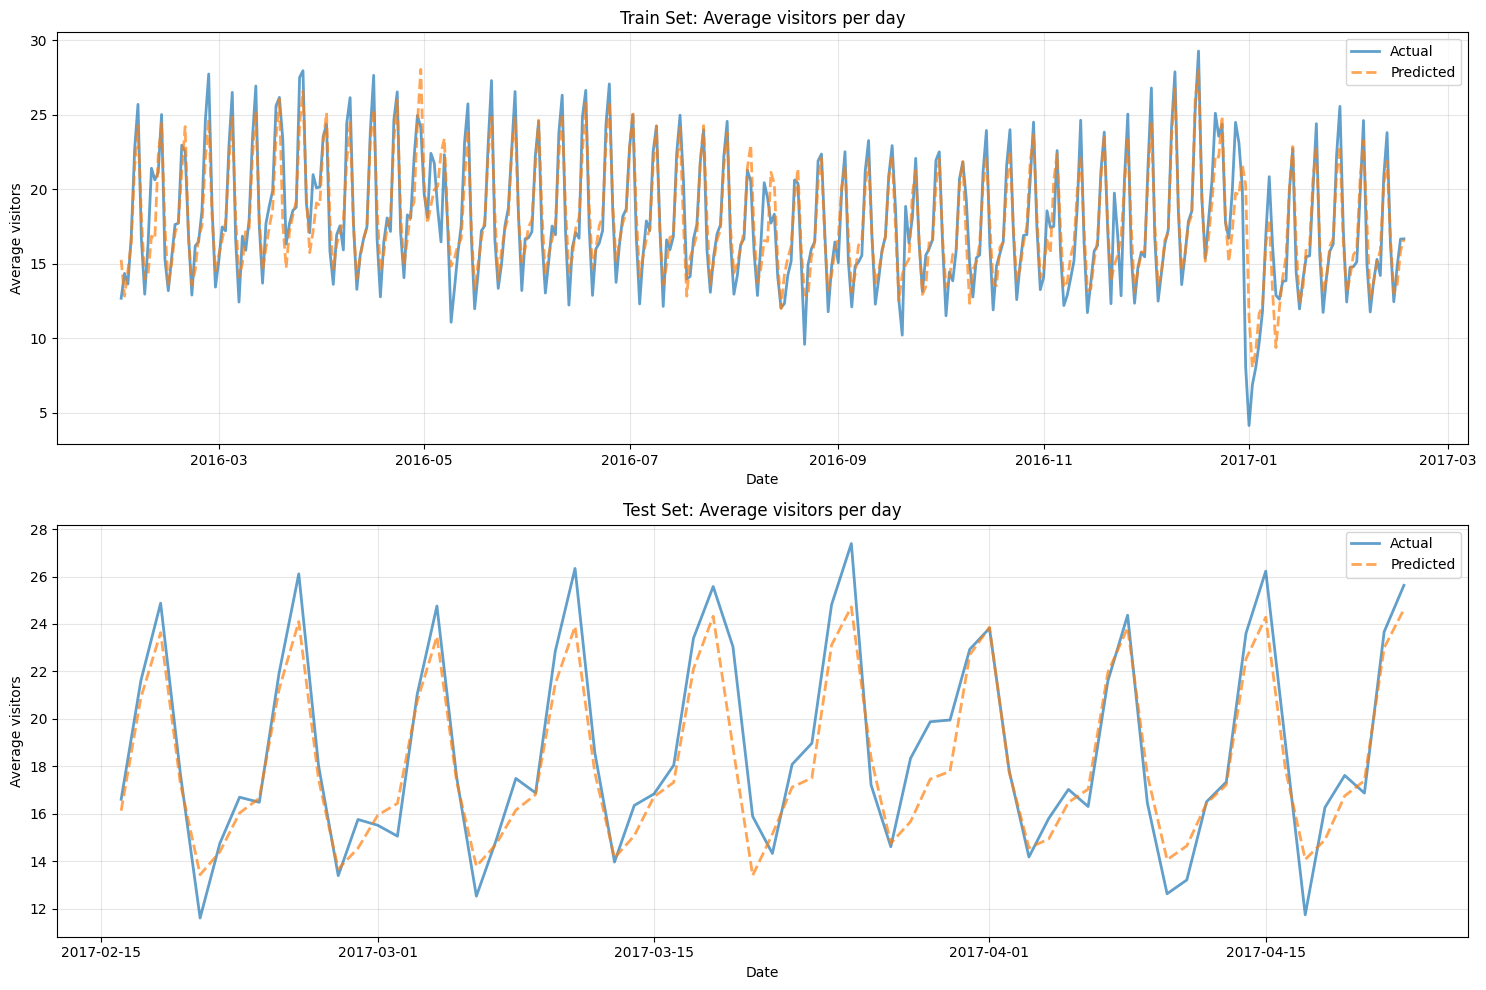

In [24]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred[0])

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [6]:
model = joblib.load(MODEL_PATH)

In [11]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [13]:
test_labels, temp_features = recursive_predict(
    model,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]C:\Users\lymuthien\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:152: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.84328828e+00 0.00000000e+00 1.01010958e+01 5.72127114e+00
 2.38862108e+01 2.54244398e+01 2.62447734e+01 6.77074431e+00
 3.71677203e+01 2.40525202e+00 2.57887778e+01 4.81534282e+00
 2.91722540e+01 4.54617232e+01 2.37004440e+01 5.87492476e+00
 1.46516961e+01 1.18165349e+01 2.49964020e+01 4.79081009e+01
 7.29078367e+00 1.60567137e+01 1.47009849e+01 1.76153260e+01
 0.00000000e+00 2.72911390e+01 1.27961827e+01 1.95468074e+01
 0.00000000e+00 1.43448402e+01 2.05898941e+01 7.95100768e+00
 1.986828

In [26]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [18]:
joblib.dump(model, MODEL_PATH)

params_to_save = {
    "best_params": convert_to_serializable(grid_search.best_params_),
    "best_score": float(grid_search.best_score_),
    "selected_features": list(selected_cols) if 'selected_cols' in globals() else None,
    "n_features": len(selected_cols) if 'selected_cols' in globals() else None,
}

params_path = MODELS_DIR / "ridge_model_params.json"
with open(params_path, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)